In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

import datetime

In [6]:
df = pd.read_csv("C:\\Users\\abhik\\Downloads\\ds_projects\\credit-card-fraud-detection-project\\data\\raw\\fraudTest.csv")

In [7]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,21-06-2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,21-06-2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,21-06-2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",21-10-1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,21-06-2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,25-07-1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,21-06-2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,06-07-1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [8]:
df.shape

(553976, 22)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553976 entries, 0 to 553975
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  553976 non-null  object 
 1   cc_num                 553976 non-null  float64
 2   merchant               553976 non-null  object 
 3   category               553976 non-null  object 
 4   amt                    553976 non-null  float64
 5   first                  553976 non-null  object 
 6   last                   553976 non-null  object 
 7   gender                 553976 non-null  object 
 8   street                 553976 non-null  object 
 9   city                   553976 non-null  object 
 10  state                  553976 non-null  object 
 11  zip                    553976 non-null  int64  
 12  lat                    553976 non-null  float64
 13  long                   553976 non-null  float64
 14  city_pop               553976 non-nu

In [12]:
df.nunique()

trans_date_trans_time    226619
cc_num                      891
merchant                    693
category                     14
amt                       36148
first                       339
last                        467
gender                        2
street                      911
city                        839
state                        50
zip                         900
lat                         898
long                        898
city_pop                    825
job                         476
dob                         897
trans_num                553976
unix_time                543081
merch_lat                544800
merch_long               550052
is_fraud                      2
dtype: int64

In [10]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [11]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,5.539760e+05,553976.000000,553976.000000,553976.000000,553976.000000,5.539760e+05,5.539760e+05,553976.000000,553976.000000,553976.000000
mean,4.182843e+17,67.932167,48844.825211,38.541985,-90.231056,8.830109e+04,1.380678e+09,38.541508,-90.231032,0.000726
std,1.310447e+18,153.237978,26855.393978,5.061831,13.722332,3.005941e+05,5.204989e+06,5.096347,13.733615,0.026928
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,1.800430e+14,9.607500,26292.000000,34.668900,-96.798000,7.410000e+02,1.376022e+09,34.755032,-96.905665,0.000000
50%,3.521420e+15,47.170000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380759e+09,39.375085,-87.443376,0.000000
75%,4.642260e+15,82.690000,72042.000000,41.894800,-80.175200,1.968500e+04,1.385870e+09,41.954249,-80.265129,0.000000
max,4.992350e+18,22768.110000,99783.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [16]:
df['is_fraud'].value_counts()

is_fraud
0    553574
1       402
Name: count, dtype: int64

In [17]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.999274
1    0.000726
Name: proportion, dtype: float64

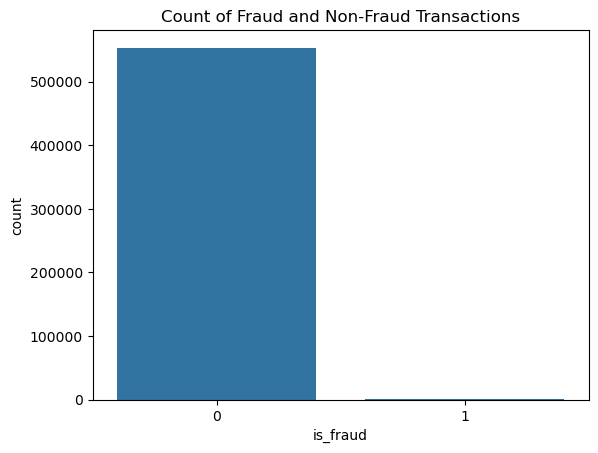

In [18]:
#Plotting the count of fraud and non-fraud transactions
sns.countplot(x='is_fraud', data=df)
plt.title('Count of Fraud and Non-Fraud Transactions')
plt.show()

In [20]:
drop_cols = [
    'first', 'last', 'street', 'trans_num'
]

df = df.drop(columns=drop_cols)

In [21]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,21-06-2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,1371816865,33.986391,-81.200714,0
1,21-06-2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,1371816873,39.450498,-109.960431,0
2,21-06-2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",21-10-1970,1371816893,40.495810,-74.196111,0
3,21-06-2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,25-07-1987,1371816915,28.812398,-80.883061,0
4,21-06-2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,06-07-1955,1371816917,44.959148,-85.884734,0


In [24]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [25]:
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek